In [18]:
import numpy as np
import numpy as np
from jax import config
import sax
from simphony.libraries import siepic, sipann
import jax.numpy as jnp
import matplotlib.pyplot as plt
from functools import partial

# we are on notebook, so enable interactive mode for plotting
plt.ion()

config.update("jax_enable_x64", True)

In [19]:
from typing import Union, Any
from jax.typing import ArrayLike

def microring(
    wl: Union[float, ArrayLike] = 1.55,
    width: float = 500.0,
    thickness: float = 220.0,
    radius: float = 10.0,
    gap: float = 100.0,
    sw_angle: float = 90.0,
) -> sax.SDict:
    out_up = sipann.half_ring(wl, width, thickness, radius, gap, sw_angle)
    out_down = sipann.half_ring(wl, width, thickness, radius, gap, sw_angle)

    return sax.SDict(
        out_up=out_up,
        out_down=out_down,
    )


microring(wl=1.55)

{'out_up': {('o0', 'o0'): array([0.+0.j]),
  ('o0', 'o1'): array([0.+0.j]),
  ('o0', 'o2'): array([-0.82782621-0.48509734j]),
  ('o0', 'o3'): array([-0.07552532-0.2714411j]),
  ('o1', 'o0'): array([0.+0.j]),
  ('o1', 'o1'): array([0.+0.j]),
  ('o1', 'o2'): array([-0.07552532-0.2714411j]),
  ('o1', 'o3'): array([-0.45831243+0.8429504j]),
  ('o2', 'o0'): array([-0.82782621-0.48509734j]),
  ('o2', 'o1'): array([-0.07552532-0.2714411j]),
  ('o2', 'o2'): array([0.+0.j]),
  ('o2', 'o3'): array([0.+0.j]),
  ('o3', 'o0'): array([-0.07552532-0.2714411j]),
  ('o3', 'o1'): array([-0.45831243+0.8429504j]),
  ('o3', 'o2'): array([0.+0.j]),
  ('o3', 'o3'): array([0.+0.j])},
 'out_down': {('o0', 'o0'): array([0.+0.j]),
  ('o0', 'o1'): array([0.+0.j]),
  ('o0', 'o2'): array([-0.82782621-0.48509734j]),
  ('o0', 'o3'): array([-0.07552532-0.2714411j]),
  ('o1', 'o0'): array([0.+0.j]),
  ('o1', 'o1'): array([0.+0.j]),
  ('o1', 'o2'): array([-0.07552532-0.2714411j]),
  ('o1', 'o3'): array([-0.45831243+0.84

# SiPANN TE-1550 Micro-Ring Resonators (MRR's)

![image](https://simphonyphotonics.readthedocs.io/en/latest/_images/ring.png)

A 4-port structure of 2 waveguides and a ring in between. The ring is coupled to the waveguides with a gap and causes a resonance effect (droping or filtering effect) at specific wavelengths. The coupling strength and the resonance wavelength can be tuned by adjusting the gap and the ring radius, respectively.

MicroRings are built upon joining 2 half-ring components. Each half-ring individually is also 4 ports: 0,1,2,3. Port *0* and *2* are the waveguide ports and port *1* and *3* are the ring ports as shown below in experiments.

The full ring we consider is build by two instances of half rings labeled: hf_up (halfring facing up), hf_down (halfring facing down). The ports of the rings are connected as hf_up,o1:hf_down,o3 and hf_up,o3:hf_down,o1.
Also, they can be further parametrized with adjustable properties to mimick experimental data:
* radius: microns (um)
* width: nanometers (nm) valid from 400 to 600nm. Default 500.
* gap: nanometers (nm). Must be greater than 100nm. Default 100.

We use the SiPANN library implementation as it provides better experimental performance
Documentation: [https://simphonyphotonics.readthedocs.io/en/latest/libs/sipann.html](https://simphonyphotonics.readthedocs.io/en/latest/libs/sipann.html)


In [20]:
circuit, info = sax.circuit(
    netlist={
        "instances": {
            "ring_up": "half_ring",
            "ring_down": "half_ring",
        },
        "connections": {
            "ring_up,o1": "ring_down,o3",
            "ring_down,o1": "ring_up,o3",
        },
        "ports": {
            "in": "ring_up,o0",
            "through": "ring_up,o2",  # through port
            "drop": "ring_down,o2", # drop port
            "add": "ring_down,o0",  # add port
        }
    },
    models={
        "half_ring": partial(sipann.half_ring, width=500, thickness=220, gap=100),
    }
)

In [21]:
wls = np.linspace(1.55, 1.6, 100)
wls = np.array([1.58,1.581])
S = circuit(wl=wls, ring_up={"radius": 10}, ring_down={"radius": 10})

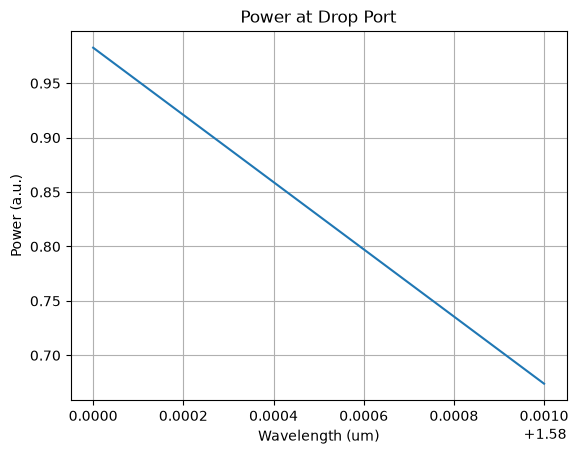

In [22]:
power = jnp.abs(S["through","in"])**2
plt.figure()
plt.plot(wls, power)
plt.xlabel("Wavelength (um)")
plt.ylabel("Power (a.u.)")
plt.title("Power at Drop Port")
plt.grid()

In [23]:
circuit, info = sax.circuit(
    netlist={
        "instances": {
            "ring_up": "half_ring",
            "ring_down": "half_ring",
        },
        "connections": {
            "ring_up,o1": "ring_down,o3",
            "ring_down,o1": "ring_up,o3",
        },
        "ports": {
            "in": "ring_up,o0",
            "through": "ring_up,o2",  # through port
            "drop": "ring_down,o2", # drop port
            "add": "ring_down,o0",  # add port
        }
    },
    models={
        "half_ring": partial(sipann.half_ring, width=500, thickness=220, gap=100),
    }
)


/var/folders/0g/n_9sx0cd2k12wcr014ctlz0m0000gn/T/ipykernel_11680/3380030167.py:47: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


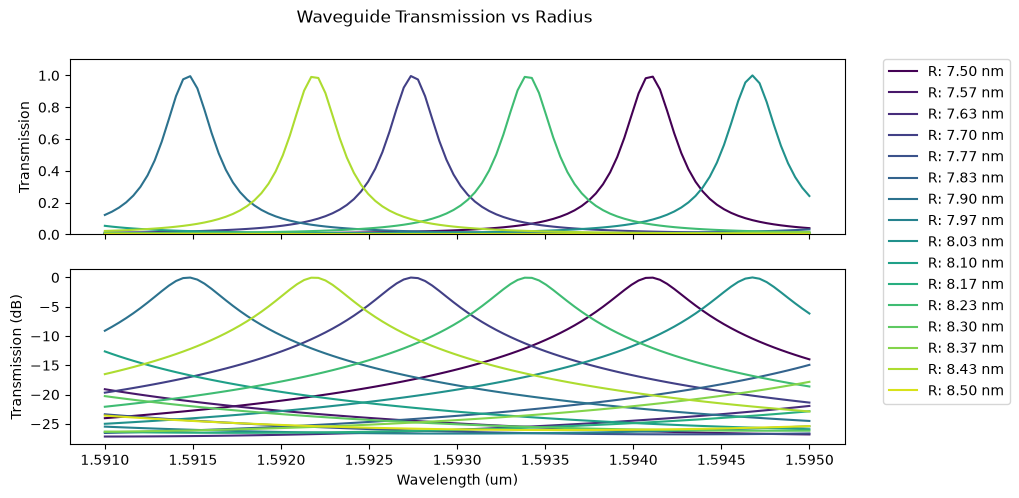

In [24]:
wls = np.linspace(1.591, 1.595, 100)
radii = np.linspace(7.5, 8.5, 16) # from 0.5 to 2 microns, 10 points

selected = ['7.50', '7.70', '7.90', '8.03', '8.23', '8.43']
selected_radii = [float(radius) for radius in selected]
# radii = selected_radii
results_per_radius = {}
for i, radius in enumerate(radii):
    S = circuit(wl=wls, ring_up={"radius": radius}, ring_down={"radius": radius})

    # Normalized power
    power = jnp.abs(S["drop","in"])**2
    # Loss
    if power.max() < 1e-6:
        loss = jnp.zeros_like(power)
    else:
        loss = 10*jnp.log10(power)
    
    radius_key = f"{radius:0.2f}"
    results_per_radius[radius_key] = {
        "wg_radius": radius,
        "power": power,
        "loss": loss,
    }

# Plot
# plot_transmission_db_plots(
#     results_per_radius, radii, wls, 
# )
# make plot twice as wide. And keep an empty padding to the right of the legend
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(10, 5))
cmap = plt.get_cmap("viridis")
axs[0].set_prop_cycle(plt.cycler(color=cmap(np.linspace(0, 1.2, len(radii)))))

for i, radius in enumerate(radii):
    radius_key = f"{radius:0.2f}"
    axs[0].plot(wls, results_per_radius[radius_key]["power"], label=f"R: {radius:0.2f} nm", color=cmap(i/len(radii)))
    axs[1].plot(wls, results_per_radius[radius_key]["loss"], label=f"R: {radius:0.2f} nm", color=cmap(i/len(radii)))

axs[0].set_ylim(0, 1.1)
axs[0].set_ylabel("Transmission")
axs[1].set_ylabel("Transmission (dB)")
axs[1].set_xlabel("Wavelength (um)")
# axs[1].legend()
axs[0].legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.suptitle("Waveguide Transmission vs Radius")
fig.show()

In [25]:
results_per_radius
# keep all radius results which for the span, they have a loss of less than -5 dB
radii_with_loss = [results_per_radius[radius]["wg_radius"] for radius in results_per_radius.keys() if results_per_radius[radius]["loss"].max() > -5]
radii_with_loss

[np.float64(7.5),
 np.float64(7.7),
 np.float64(7.9),
 np.float64(8.033333333333333),
 np.float64(8.233333333333333),
 np.float64(8.433333333333334)]

/var/folders/0g/n_9sx0cd2k12wcr014ctlz0m0000gn/T/ipykernel_11680/2577427520.py:52: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


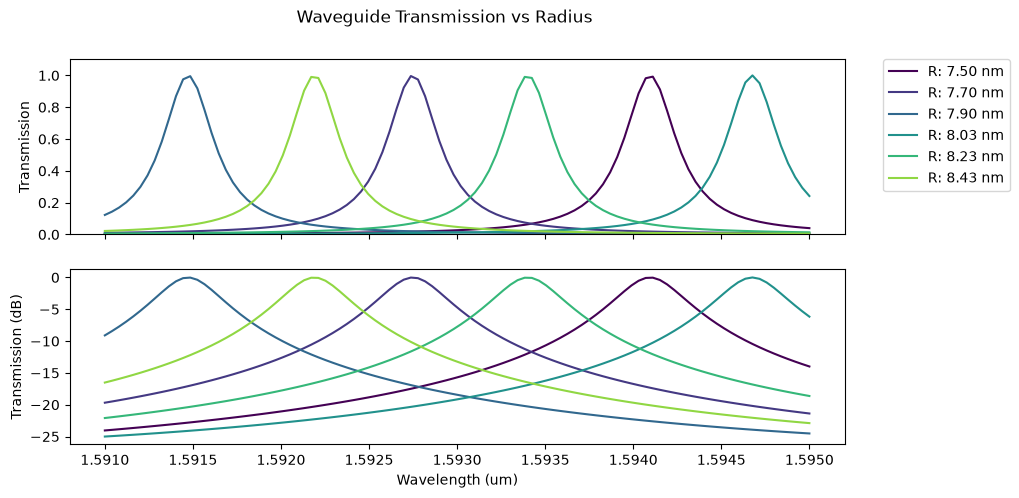

In [26]:
wls = np.linspace(1.591, 1.595, 100)
radii = np.linspace(7.5, 8.5, 16) # from 0.5 to 2 microns, 10 points

selected = ['7.50', '7.70', '7.90', '8.03', '8.23', '8.43']
selected_radii = [float(radius) for radius in selected]
radii = [np.float64(7.5),
 np.float64(7.7),
 np.float64(7.9),
 np.float64(8.033333333333333),
 np.float64(8.233333333333333),
 np.float64(8.433333333333334)]
results_per_radius = {}
for i, radius in enumerate(radii):
    S = circuit(wl=wls, ring_up={"radius": radius}, ring_down={"radius": radius})

    # Normalized power
    power = jnp.abs(S["drop","in"])**2
    # Loss
    if power.max() < 1e-6:
        loss = jnp.zeros_like(power)
    else:
        loss = 10*jnp.log10(power)
    
    radius_key = f"{radius:0.2f}"
    results_per_radius[radius_key] = {
        "wg_radius": radius,
        "power": power,
        "loss": loss,
    }

# Plot
# plot_transmission_db_plots(
#     results_per_radius, radii, wls, 
# )
# make plot twice as wide. And keep an empty padding to the right of the legend
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(10, 5))
cmap = plt.get_cmap("viridis")
axs[0].set_prop_cycle(plt.cycler(color=cmap(np.linspace(0, 1.2, len(radii)))))

for i, radius in enumerate(radii):
    radius_key = f"{radius:0.2f}"
    axs[0].plot(wls, results_per_radius[radius_key]["power"], label=f"R: {radius:0.2f} nm", color=cmap(i/len(radii)))
    axs[1].plot(wls, results_per_radius[radius_key]["loss"], label=f"R: {radius:0.2f} nm", color=cmap(i/len(radii)))

axs[0].set_ylim(0, 1.1)
axs[0].set_ylabel("Transmission")
axs[1].set_ylabel("Transmission (dB)")
axs[1].set_xlabel("Wavelength (um)")
# axs[1].legend()
axs[0].legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.suptitle("Waveguide Transmission vs Radius")
fig.show()

In [27]:
results_per_radius
# keep all radius results which for the span, they have a loss of less than -5 dB
radii_with_loss = [radius for radius in results_per_radius.keys() if results_per_radius[radius]["loss"].max() > -5]
radii_with_loss

['7.50', '7.70', '7.90', '8.03', '8.23', '8.43']

In [33]:
# results_per_radius entries ['7.50', '7.70', etc] have a property 'power' with an array of same size as wls.
# power[0] is the "power" output of drop port at wavelength wls[0] for the given radius.
# for each radius, we want to find the wavelength at which the power is maximum, and the corresponding power value and store them in results_per_radius[radius]["max_power"] and results_per_radius[radius]["max_power_wl"]
for radius in results_per_radius.keys():
    power = results_per_radius[radius]["power"]
    max_power_idx = jnp.argmax(power)
    max_power = power[max_power_idx]
    max_power_wl = wls[max_power_idx]
    results_per_radius[radius]["max_power"] = max_power
    results_per_radius[radius]["max_power_wl"] = max_power_wl

peak_wavelengths = {radius: results_per_radius[radius]["max_power_wl"] for radius in results_per_radius.keys()}
peak_wavelengths

{'7.50': np.float64(1.594111111111111),
 '7.70': np.float64(1.5927373737373738),
 '7.90': np.float64(1.5914848484848485),
 '8.03': np.float64(1.5946767676767677),
 '8.23': np.float64(1.5933838383838383),
 '8.43': np.float64(1.5921717171717171)}

In [28]:
keys = list(results_per_radius.keys())
results_per_radius[keys[0]]["loss"].max()

Array(-0.03363695, dtype=float64)